In [1]:
# imports

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

import requests

# ML regression method (curve approximation of frontier)
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

## Step 1: Choose an ETF with a minimum of 100 assets

In [2]:
# ETF selection
our_etf = ["QQQ"]

## Step 2: Identify the assets that constitute your chosen ETF


In [3]:
url = "https://companiesmarketcap.com/invesco-qqq-trust/holdings/"

# 1. Define a standard browser header to mask the Python automation signature
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
    'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8',
    'Accept-Language': 'en-US,en;q=0.5'
}

try:
    # 2. Safely grab the webpage HTML content using the headers
    response = requests.get(url, headers=headers)
    response.raise_for_status()  # Check if the connection successfully returned HTTP 200
    
    # 3. Hand the raw text over to Pandas to parse out the tables
    tables = pd.read_html(response.text)
    qqq_holdings_df = tables[0]
    
    # 4. Clean column whitespaces
    qqq_holdings_df.columns = [col.strip() for col in qqq_holdings_df.columns]
    
    print(f"Bypass successful! Retrieved {len(qqq_holdings_df)} QQQ holdings.\n")
    print(qqq_holdings_df.head(15))

except Exception as e:
    print(f"Connection failed: {e}")

Bypass successful! Retrieved 104 QQQ holdings.

   Weight %                        Name Ticker  Shares Held
0     9.08%                 NVIDIA Corp   NVDA  188810650.0
1     7.31%                   Apple Inc   AAPL  114072213.0
2     5.20%              Microsoft Corp   MSFT   57697024.0
3     4.70%              Amazon.com Inc   AMZN   83410188.0
4     3.83%                Alphabet Inc  GOOGL   45236823.0
5     3.74%       Micron Technology Inc     MU   24142751.0
6     3.55%                Alphabet Inc   GOOG   42253127.0
7     3.50%                   Tesla Inc   TSLA   38780756.0
8     3.34%                Broadcom Inc   AVGO   36839661.0
9     3.17%  Advanced Micro Devices Inc    AMD   34973097.0
10    3.01%          Meta Platforms Inc   META   22916490.0
11    2.95%                 Walmart Inc    WMT  104833719.0
12    2.49%                  Intel Corp   INTC  107145313.0
13    2.14%           Cisco Systems Inc   CSCO   84727172.0
14    2.13%       Costco Wholesale Corp   COST    95

C:\Users\alesu\AppData\Local\Temp\ipykernel_21404\2858492097.py:16: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


In [4]:
qqq_holdings_df

,Weight %,Name,Ticker,Shares Held
0,9.08%,NVIDIA Corp,NVDA,1.888106e+08
1,7.31%,Apple Inc,AAPL,1.140722e+08
2,5.20%,Microsoft Corp,MSFT,5.769702e+07
3,4.70%,Amazon.com Inc,AMZN,8.341019e+07
4,3.83%,Alphabet Inc,GOOGL,4.523682e+07
...,...,...,...,...
99,0.10%,CASH & EQUIVALENTS,USD,4.562514e+08
100,0.08%,Charter Communications Inc,CHTR,2.716354e+06
101,0.08%,CME E-Mini NASDAQ 100 Index Future,NQM6,6.500000e+02
102,0.06%,CoStar Group Inc,CSGP,9.004740e+06


## Step 3: Retrieve historical data for your chosen ETF and each asset


In [5]:
price_data = yf.download(our_etf + [str(qqq) for qqq in qqq_holdings_df["Ticker"].tolist()], start="2020-01-01", end="2026-01-01")["Close"]

[**********************68%********               ]  71 of 105 completedHTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: NQM6"}}}
[**********************69%********               ]  72 of 105 completed$NQM6: possibly delisted; no timezone found
[*********************100%***********************]  105 of 105 completed

1 Failed download:
['NQM6']: possibly delisted; no timezone found


In [6]:
price_data.head()

Ticker,AAPL,ABNB,ADBE,ADI,ADP,ADSK,AEP,ALNY,AMAT,AMD,...,TXN,USD,VRSK,VRTX,WBD,WDAY,WDC,WMT,XEL,ZS
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,72.333885,NaN,334.429993,107.791656,148.655548,187.830002,74.227936,115.620003,58.699459,49.099998,...,107.939438,3.953887,145.076416,219.449997,32.220001,167.460007,48.747662,36.289963,51.483532,47.330002
2020-01-03,71.630630,NaN,331.809998,105.894135,148.341370,184.949997,74.148521,115.680000,57.765175,48.599998,...,106.506577,3.827496,146.487671,217.979996,32.029999,168.440002,47.997360,35.969589,51.731129,47.380001
2020-01-06,72.201416,NaN,333.709991,104.650009,148.542099,187.119995,74.394730,115.970001,56.519463,48.389999,...,105.765144,3.766458,146.823669,224.029999,31.959999,169.490005,47.076183,35.896355,51.656849,48.700001
2020-01-07,71.861855,NaN,333.390015,107.030853,146.744095,187.500000,74.410622,115.290001,58.152096,48.250000,...,107.806168,3.857090,148.052475,223.789993,32.070000,172.949997,50.263134,35.563789,51.549561,48.400002
2020-01-08,73.017838,NaN,337.869995,107.997543,148.123123,189.949997,74.188232,115.470001,58.114361,47.830002,...,108.097733,3.853391,149.415680,231.089996,32.110001,178.710007,50.991154,35.441750,51.500042,50.750000


In [7]:
# dropping unnecessary columns
# `ABNB` is a recent addition to the QQQ holdings, but it has very limited historical data, so we will drop it for now
price_data = price_data.drop(columns=["NAN", "USD", "ABNB"])
price_data.head()

Ticker,AAPL,ADBE,ADI,ADP,ADSK,AEP,ALNY,AMAT,AMD,AMGN,...,TTWO,TXN,VRSK,VRTX,WBD,WDAY,WDC,WMT,XEL,ZS
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,72.333885,334.429993,107.791656,148.655548,187.830002,74.227936,115.620003,58.699459,49.099998,196.748108,...,122.080002,107.939438,145.076416,219.449997,32.220001,167.460007,48.747662,36.289963,51.483532,47.330002
2020-01-03,71.630630,331.809998,105.894135,148.341370,184.949997,74.148521,115.680000,57.765175,48.599998,195.412384,...,122.209999,106.506577,146.487671,217.979996,32.029999,168.440002,47.997360,35.969589,51.731129,47.380001
2020-01-06,72.201416,333.709991,104.650009,148.542099,187.119995,74.394730,115.970001,56.519463,48.389999,196.911957,...,124.690002,105.765144,146.823669,224.029999,31.959999,169.490005,47.076183,35.896355,51.656849,48.700001
2020-01-07,71.861855,333.390015,107.030853,146.744095,187.500000,74.410622,115.290001,58.152096,48.250000,195.060013,...,125.510002,107.806168,148.052475,223.789993,32.070000,172.949997,50.263134,35.563789,51.549561,48.400002
2020-01-08,73.017838,337.869995,107.997543,148.123123,189.949997,74.188232,115.470001,58.114361,47.830002,195.207550,...,127.820000,108.097733,149.415680,231.089996,32.110001,178.710007,50.991154,35.441750,51.500042,50.750000


In [8]:
# volume data
# Source: https://algotrading101.com/learn/yfinance-guide/
volume_data = yf.download(our_etf + [str(qqq) for qqq in qqq_holdings_df["Ticker"].tolist()], start="2020-01-01", end="2026-01-01")["Volume"]

[**********************66%*******                ]  69 of 105 completedHTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: NQM6"}}}
[**********************70%*********              ]  74 of 105 completed$NQM6: possibly delisted; no timezone found
[*********************100%***********************]  105 of 105 completed

1 Failed download:
['NQM6']: possibly delisted; no timezone found


In [9]:
volume_data = volume_data.drop(columns=["NAN", "NQM6", "USD", "ABNB"])
volume_data.head()

Ticker,AAPL,ADBE,ADI,ADP,ADSK,AEP,ALNY,AMAT,AMD,AMGN,...,TTWO,TXN,VRSK,VRTX,WBD,WDAY,WDC,WMT,XEL,ZS
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,135480400,1990100,1279300,1364600,1515000,1779700,593500,6647900,80331100,2088000,...,1114200,4614000,845100,1334300,3249300,1503000,8823749,20294700,2915400,1377200
2020-01-03,146322800,1577600,1374400,1000100,737900,1939400,426000,5415200,73127400,1879000,...,729100,4057200,876900,943400,3599600,1276300,5236434,16197600,2422500,1165200
2020-01-06,118387200,1874700,1979400,1205900,1021900,1253200,668600,8586000,47934900,1802800,...,1678700,4345400,656200,1436600,2416900,1623300,5405646,19336500,2217100,1534600
2020-01-07,108872000,2500800,2214700,1878900,897200,2608100,392300,7970400,58061400,1518900,...,1179300,7184100,1514700,1027700,3102000,2404100,14672467,20540700,1861100,1714900
2020-01-08,132079200,2248500,2036500,1675500,1314800,2245400,554400,4364400,53767000,2214700,...,1665900,3546900,773100,1802600,3674100,2819900,8731932,17627400,4828900,3232500


In [10]:
# further data cleaning: dropping rows with missing values
price_data.shape
price_data.index.min(), price_data.index.max()
price_data.isna().sum().sort_values(ascending=False).head(20)
price_data.columns.tolist()

volume_data.shape
volume_data.index.min(), volume_data.index.max()
volume_data.isna().sum().sort_values(ascending=False).head(20)
volume_data.columns.tolist()

['AAPL',
 'ADBE',
 'ADI',
 'ADP',
 'ADSK',
 'AEP',
 'ALNY',
 'AMAT',
 'AMD',
 'AMGN',
 'AMZN',
 'APP',
 'ARM',
 'ASML',
 'AVGO',
 'AXON',
 'BKNG',
 'BKR',
 'CCEP',
 'CDNS',
 'CEG',
 'CHTR',
 'CMCSA',
 'COST',
 'CPRT',
 'CRWD',
 'CSCO',
 'CSGP',
 'CSX',
 'CTAS',
 'CTSH',
 'DASH',
 'DDOG',
 'DXCM',
 'EA',
 'EXC',
 'FANG',
 'FAST',
 'FER',
 'FTNT',
 'GEHC',
 'GILD',
 'GOOG',
 'GOOGL',
 'HON',
 'IDXX',
 'INSM',
 'INTC',
 'INTU',
 'ISRG',
 'KDP',
 'KHC',
 'KLAC',
 'LIN',
 'LRCX',
 'MAR',
 'MCHP',
 'MDLZ',
 'MELI',
 'META',
 'MNST',
 'MPWR',
 'MRVL',
 'MSFT',
 'MSTR',
 'MU',
 'NFLX',
 'NVDA',
 'NXPI',
 'ODFL',
 'ORLY',
 'PANW',
 'PAYX',
 'PCAR',
 'PDD',
 'PEP',
 'PLTR',
 'PYPL',
 'QCOM',
 'QQQ',
 'REGN',
 'ROP',
 'ROST',
 'SBUX',
 'SHOP',
 'SNDK',
 'SNPS',
 'STX',
 'TMUS',
 'TRI',
 'TSLA',
 'TTWO',
 'TXN',
 'VRSK',
 'VRTX',
 'WBD',
 'WDAY',
 'WDC',
 'WMT',
 'XEL',
 'ZS']

## Step 4: Calculate the Barry Cox price momentum factors for each asset in your ETF


#### Slope of 52 Week Trend Line

In [11]:
# shift prices back by 20 days
lagged_prices = price_data.shift(20)

def calculate_trend_slope(window_prices):
    """
    Calculates normalized slope of a price trend line.
    window_prices should contain about 252 daily prices.
    """

    y = window_prices.dropna().values

    if len(y) < 252:
        return np.nan

    x = np.arange(len(y))

    slope, intercept = np.polyfit(x, y, 1)

    normalized_slope = slope / np.mean(y)

    return normalized_slope

In [12]:
trend_52w = lagged_prices.rolling(window=252).apply(calculate_trend_slope, raw=False)

In [13]:
trend_52w.iloc[268: 280]

Ticker,AAPL,ADBE,ADI,ADP,ADSK,AEP,ALNY,AMAT,AMD,AMGN,...,TTWO,TXN,VRSK,VRTX,WBD,WDAY,WDC,WMT,XEL,ZS
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-29,0.002849,0.001939,0.001111,0.000147,0.002003,-0.000341,0.000626,0.001527,0.003227,0.000394,...,0.002133,0.001579,0.001252,-0.000006,-0.000531,0.001691,-0.001591,0.001245,0.000493,0.005264
2021-02-01,0.002859,0.001936,0.001137,0.000173,0.002021,-0.000337,0.000613,0.001563,0.003232,0.000397,...,0.002151,0.001598,0.001257,-0.000024,-0.000472,0.001704,-0.001534,0.001247,0.000487,0.005263
2021-02-02,0.002865,0.001930,0.001160,0.000195,0.002034,-0.000335,0.000598,0.001597,0.003237,0.000398,...,0.002166,0.001615,0.001260,-0.000045,-0.000413,0.001711,-0.001485,0.001249,0.000481,0.005259
2021-02-03,0.002873,0.001924,0.001183,0.000217,0.002049,-0.000332,0.000584,0.001633,0.003242,0.000400,...,0.002183,0.001631,0.001263,-0.000064,-0.000350,0.001718,-0.001436,0.001251,0.000473,0.005253
2021-02-04,0.002875,0.001913,0.001209,0.000237,0.002065,-0.000329,0.000568,0.001673,0.003243,0.000404,...,0.002199,0.001649,0.001266,-0.000084,-0.000275,0.001724,-0.001379,0.001252,0.000467,0.005240
2021-02-05,0.002883,0.001906,0.001241,0.000258,0.002086,-0.000328,0.000562,0.001718,0.003248,0.000408,...,0.002220,0.001670,0.001269,-0.000099,-0.000200,0.001735,-0.001316,0.001253,0.000459,0.005234


In [14]:
# resample to monthly frequency by taking the last value of each month
monthly_trend_52w = trend_52w.resample("M").last()

monthly_trend_52w.tail(5)

Ticker,AAPL,ADBE,ADI,ADP,ADSK,AEP,ALNY,AMAT,AMD,AMGN,...,TTWO,TXN,VRSK,VRTX,WBD,WDAY,WDC,WMT,XEL,ZS
Date,,,,,,,,,,,,,,,,,,,,,
2025-08-31,-0.000502,-0.001819,0.000047,0.000625,0.000423,0.000502,0.000637,-0.000609,-0.000951,-0.000375,...,0.002088,-0.000220,0.000648,-0.000112,0.001462,-0.000052,0.000787,0.001121,0.000681,0.002246
2025-09-30,-0.000477,-0.001834,0.000213,0.000428,0.000184,0.000644,0.001676,-0.000393,-0.000136,-0.000228,...,0.001861,-0.000107,0.000365,-0.000342,0.001399,-0.000393,0.001537,0.000872,0.000571,0.002355
2025-10-31,-0.000248,-0.001652,0.000502,0.000198,0.000216,0.000769,0.002536,-0.000001,0.000642,-0.000054,...,0.001713,-0.000056,-0.000006,-0.000559,0.002194,-0.000469,0.003103,0.000753,0.000601,0.002281
2025-11-30,0.000054,-0.001604,0.000685,0.000008,0.000229,0.000918,0.003160,0.000720,0.002280,0.000151,...,0.001531,-0.000091,-0.000417,-0.000600,0.002733,-0.000569,0.004343,0.000666,0.000714,0.002342
2025-12-31,0.000450,-0.001477,0.000794,-0.000303,0.000311,0.001049,0.003358,0.001409,0.003463,0.000524,...,0.001295,-0.000134,-0.000864,-0.000539,0.003708,-0.000640,0.005841,0.000579,0.000886,0.002262


#### Percent Above 260 Day Low

In [48]:
low_260 = lagged_prices.rolling(window=260).min()

pct_above_260_low = (lagged_prices - low_260) / low_260

In [49]:
pct_above_260_low.tail(5)

Ticker,AAPL,ADBE,ADI,ADP,ADSK,AEP,ALNY,AMAT,AMD,AMGN,...,TTWO,TXN,VRSK,VRTX,WBD,WDAY,WDC,WMT,XEL,ZS
Date,,,,,,,,,,,,,,,,,,,,,
2025-12-24,0.611861,0.022887,0.544160,0.029110,0.232750,0.393014,0.916013,0.924571,1.635597,0.362053,...,0.361558,0.138632,0.072212,0.172641,1.985696,0.110325,4.104153,0.314454,0.299946,0.658728
2025-12-26,0.615237,0.016389,0.580310,0.021160,0.261849,0.406076,0.984308,0.984183,1.739292,0.375869,...,0.371636,0.163830,0.076394,0.179053,2.105331,0.023139,4.180678,0.340252,0.313852,0.442549
2025-12-29,0.622802,0.024744,0.625773,0.025054,0.270055,0.418107,1.011546,1.002281,1.781358,0.379422,...,0.385373,0.184382,0.082067,0.182981,2.120936,0.024469,4.364270,0.357573,0.327759,0.439858
2025-12-30,0.647536,0.033451,0.632942,0.027222,0.277508,0.380755,1.026391,1.022125,1.809871,0.347598,...,0.403783,0.183608,0.076971,0.161128,2.104031,0.013684,4.371167,0.370104,0.289273,0.392798
2025-12-31,0.665518,0.033323,0.672523,0.032603,0.298987,0.366089,1.072619,1.106106,1.752078,0.351072,...,0.381950,0.233582,0.081010,0.181726,2.189857,0.012306,4.254574,0.380914,0.278116,0.383638


In [50]:
monthly_pct_above_260_low = pct_above_260_low.resample("M").last()

#### 4/52 Week Price Oscillator

In [51]:
ma_4w = lagged_prices.rolling(window=20).mean()
ma_52w = lagged_prices.rolling(window=252).mean()

price_oscillator_4w_52w = ((ma_4w - ma_52w) / ma_52w)

In [52]:
# monthly
monthly_price_oscillator_4w_52w = price_oscillator_4w_52w.resample("M").last()

#### 39 Week Return

In [53]:
return_39w = (lagged_prices/lagged_prices.shift(195)) - 1
monthly_return_39w = return_39w.resample("M").last()

#### 51 week Volume Price trend

In [54]:
lagged_volume = volume_data.shift(20)

daily_returns = lagged_prices.pct_change()

daily_vpt = lagged_volume * daily_returns

vpt_51w = daily_vpt.rolling(window=252).sum()

monthly_vpt_51w = vpt_51w.resample("M").last()

C:\Users\alesu\AppData\Local\Temp\ipykernel_21404\3021685840.py:3: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  daily_returns = lagged_prices.pct_change()


## Step 5: Using the price momentum factors, calculate the monthly z-factor score for each asset


In [55]:
# what we have got so far
#  - monthly_trend_52w - Slope of 52 Week Trend Line
#  - monthly_pct_above_260_low - Percentage above 260 Week Low
#  - monthly_price_oscillator_4w_52w - Price Oscillator between 4 Week and 52 Week Moving Averages
#  - monthly_return_39w - Return over the past 39 Weeks
#  - monthly_vpt_51w - Volume Price Trend over the past 51 Weeks

#### z-score calculation

In [56]:
# for each month, compare every stock against all other stocks
def cross_sectional_zscore(factor_data):
    return factor_data.sub(factor_data.mean(axis=1), axis=0).div(
        factor_data.std(axis=1), axis=0)


In [57]:
# removing `QQQ` from the factor dataframes, since it is not a stock but an ETF
monthly_trend_52w = monthly_trend_52w.drop(columns=["QQQ"])
monthly_pct_above_260_low = monthly_pct_above_260_low.drop(columns=["QQQ"])
monthly_price_oscillator_4w_52w = monthly_price_oscillator_4w_52w.drop(columns=["QQQ"])
monthly_return_39w = monthly_return_39w.drop(columns=["QQQ"])  
monthly_vpt_51w = monthly_vpt_51w.drop(columns=["QQQ"])

# z-score normalization for each factor
z_trend_52w = cross_sectional_zscore(monthly_trend_52w)
z_pct_above_260_low = cross_sectional_zscore(monthly_pct_above_260_low)
z_price_oscillator_4w_52w = cross_sectional_zscore(monthly_price_oscillator_4w_52w)
z_return_39w = cross_sectional_zscore(monthly_return_39w)
z_vpt_51w = cross_sectional_zscore(monthly_vpt_51w)

combined_z_score = (
    z_trend_52w +
    z_pct_above_260_low +
    z_price_oscillator_4w_52w +
    z_return_39w +
    z_vpt_51w
) / 5



KeyError: "['QQQ'] not found in axis"

In [58]:
combined_z_score.tail()

Ticker,AAPL,ADBE,ADI,ADP,ADSK,AEP,ALNY,AMAT,AMD,AMGN,...,TTWO,TXN,VRSK,VRTX,WBD,WDAY,WDC,WMT,XEL,ZS
Date,,,,,,,,,,,,,,,,,,,,,
2025-08-31,-0.717384,-1.219618,-0.278175,-0.254308,-0.263997,-0.144109,0.299583,-0.395990,0.206829,-0.524167,...,0.489010,-0.408147,-0.318028,-0.498123,1.068876,-0.600981,0.799132,0.085511,-0.096178,0.797331
2025-09-30,-0.389199,-1.265129,-0.047026,-0.331463,-0.304424,-0.051537,1.354028,-0.589302,0.394016,-0.465574,...,0.400106,-0.370542,-0.535168,-0.816775,0.624762,-0.719865,1.290240,-0.007516,-0.185151,0.643131
2025-10-31,-0.253126,-1.066122,-0.134798,-0.492812,-0.287693,-0.129352,1.042370,-0.097885,0.318727,-0.436870,...,0.332518,-0.519101,-0.678556,-0.727915,2.101941,-0.686471,2.625059,-0.182647,-0.134707,0.600307
2025-11-30,-0.046749,-1.005807,-0.215311,-0.613643,-0.385154,-0.033977,0.918418,0.117066,1.933565,-0.391787,...,0.183478,-0.658601,-0.810514,-0.656267,2.355833,-0.645302,2.656447,-0.217838,-0.072573,0.595399
2025-12-31,0.088967,-0.909487,-0.059369,-0.670490,-0.314424,-0.063481,0.823081,0.455875,1.784864,-0.148448,...,-0.083062,-0.566154,-0.809544,-0.576205,2.564860,-0.680859,3.210293,-0.154453,-0.127520,0.124935


## Step 6: Identify long and short baskets (10 to 15 assets in each) using calculated z-factors


#### Ranking Stocks

In [59]:
long_basket = combined_z_score.apply(
    lambda row: row.nlargest(15).index.tolist(),
    axis=1
)

short_basket = combined_z_score.apply(
    lambda row: row.nsmallest(15).index.tolist(),
    axis=1
)

## Step 7: Create a backtest to validate performance of your algorithm based on monthly restructuring over the previous 5 years.

#### create monthly stock returns

In [60]:
monthly_prices = price_data.resample("M").last()

monthly_returns = monthly_prices.pct_change()

etf_returns = monthly_returns["QQQ"]
monthly_returns = monthly_returns.drop(columns=["QQQ"])

C:\Users\alesu\AppData\Local\Temp\ipykernel_21404\3938471227.py:3: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  monthly_returns = monthly_prices.pct_change()


#### shift returns backward for next-month performance

In [61]:
next_month_returns = monthly_returns.shift(-1)
next_month_etf_returns = etf_returns.shift(-1)

#### back test look

In [62]:
backtest_results = []

num_stocks = 15

for date in combined_z_score.index:
    scores = combined_z_score.loc[date].dropna()
    
    if len(scores) < num_stocks * 2:
        continue
    
    long_tickers = scores.nlargest(num_stocks).index
    short_tickers = scores.nsmallest(num_stocks).index
    
    if date not in next_month_returns.index:
        continue
    
    returns = next_month_returns.loc[date]
    
    long_return = returns[long_tickers].mean()
    short_return = returns[short_tickers].mean()
    
    portfolio_return = long_return - short_return
    
    etf_return = next_month_etf_returns.loc[date]
    
    backtest_results.append({
        "Date": date,
        "Long Return": long_return,
        "Short Return": short_return,
        "Portfolio Return": portfolio_return,
        "ETF Return": etf_return,
        "Long Tickers": list(long_tickers),
        "Short Tickers": list(short_tickers)
    })

In [63]:
backtest_df = pd.DataFrame(backtest_results)
backtest_df = backtest_df.set_index("Date")

In [64]:
backtest_df.head()

,Long Return,Short Return,Portfolio Return,ETF Return,Long Tickers,Short Tickers
Date,,,,,,
2021-02-28,-0.083199,0.077802,-0.161001,0.017168,"[TSLA, MSTR, PDD, CRWD, ZS, NVDA, MELI, DDOG, ...","[GILD, INTC, VRTX, AEP, FER, REGN, XEL, CSCO, ..."
2021-03-31,0.044076,0.027165,0.016911,0.059098,"[MSTR, TSLA, PDD, CRWD, NVDA, ZS, WBD, MELI, F...","[VRTX, REGN, GILD, AEP, XEL, INTC, FER, AMGN, ..."
2021-04-30,-0.024486,-0.001227,-0.023259,-0.012012,"[MSTR, TSLA, WBD, AMAT, NVDA, FANG, PDD, CRWD,...","[VRTX, REGN, GILD, FER, DXCM, XEL, ALNY, AEP, ..."
2021-05-31,0.089349,0.031805,0.057545,0.062621,"[MSTR, TSLA, AMAT, NVDA, FANG, CRWD, LRCX, STX...","[VRTX, REGN, GILD, ALNY, DXCM, FER, AMGN, AEP,..."
2021-06-30,-0.012696,0.029575,-0.042271,0.028609,"[MSTR, TSLA, FANG, AMAT, STX, NVDA, WDC, LRCX,...","[VRTX, REGN, DXCM, INSM, VRSK, ALNY, DDOG, GIL..."


#### Calculate cumulative returns

In [65]:
backtest_df["Cumulative Portfolio Return"] = (
    1 + backtest_df["Portfolio Return"]
).cumprod() - 1

In [66]:
backtest_df["Cumulative ETF Return"] = (
    1 + backtest_df["ETF Return"]
).cumprod() - 1

In [67]:
backtest_df[["Long Return", "Short Return", "Portfolio Return", "ETF Return"]].head()

,Long Return,Short Return,Portfolio Return,ETF Return
Date,,,,
2021-02-28,-0.083199,0.077802,-0.161001,0.017168
2021-03-31,0.044076,0.027165,0.016911,0.059098
2021-04-30,-0.024486,-0.001227,-0.023259,-0.012012
2021-05-31,0.089349,0.031805,0.057545,0.062621
2021-06-30,-0.012696,0.029575,-0.042271,0.028609


In [68]:
backtest_df[["Portfolio Return", "ETF Return"]].describe()

,Portfolio Return,ETF Return
count,58.000000,58.000000
mean,0.004905,0.013746
std,0.083320,0.056716
min,-0.236004,-0.135957
25%,-0.041389,-0.015802
50%,0.009013,0.017680
75%,0.058299,0.055022
max,0.213830,0.125518


## Step 8: Chart:
### 1. Monthly portfolio return bar chart (pos/neg coloring) vs ETF


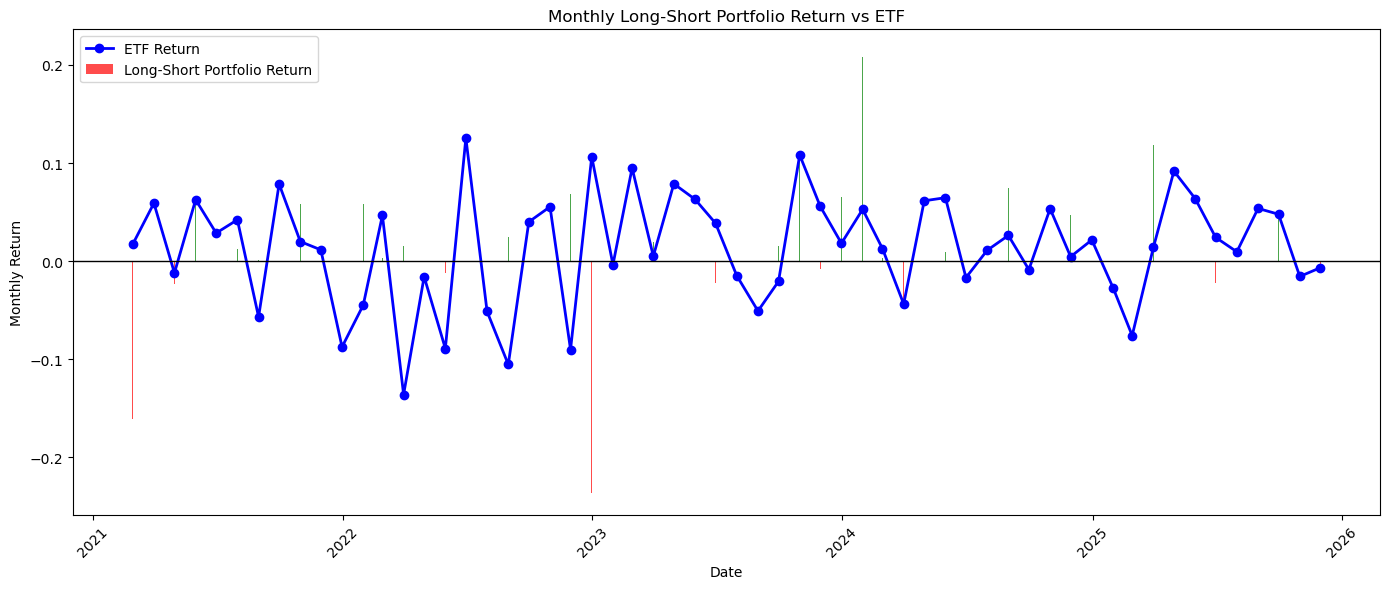

In [69]:
# Positive returns green, negative returns red
colors = np.where(backtest_df["Portfolio Return"] >= 0, "green", "red")

plt.figure(figsize=(14, 6))

plt.bar(
    backtest_df.index,
    backtest_df["Portfolio Return"],
    color=colors,
    alpha=0.7,
    label="Long-Short Portfolio Return"
)

plt.plot(
    backtest_df.index,
    backtest_df["ETF Return"],
    color="blue",
    marker="o",
    linewidth=2,
    label="ETF Return"
)

plt.axhline(0, color="black", linewidth=1)

plt.title("Monthly Long-Short Portfolio Return vs ETF")
plt.xlabel("Date")
plt.ylabel("Monthly Return")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 8: Chart:

### 2. Monthly return for long picks vs short picks vs ETF


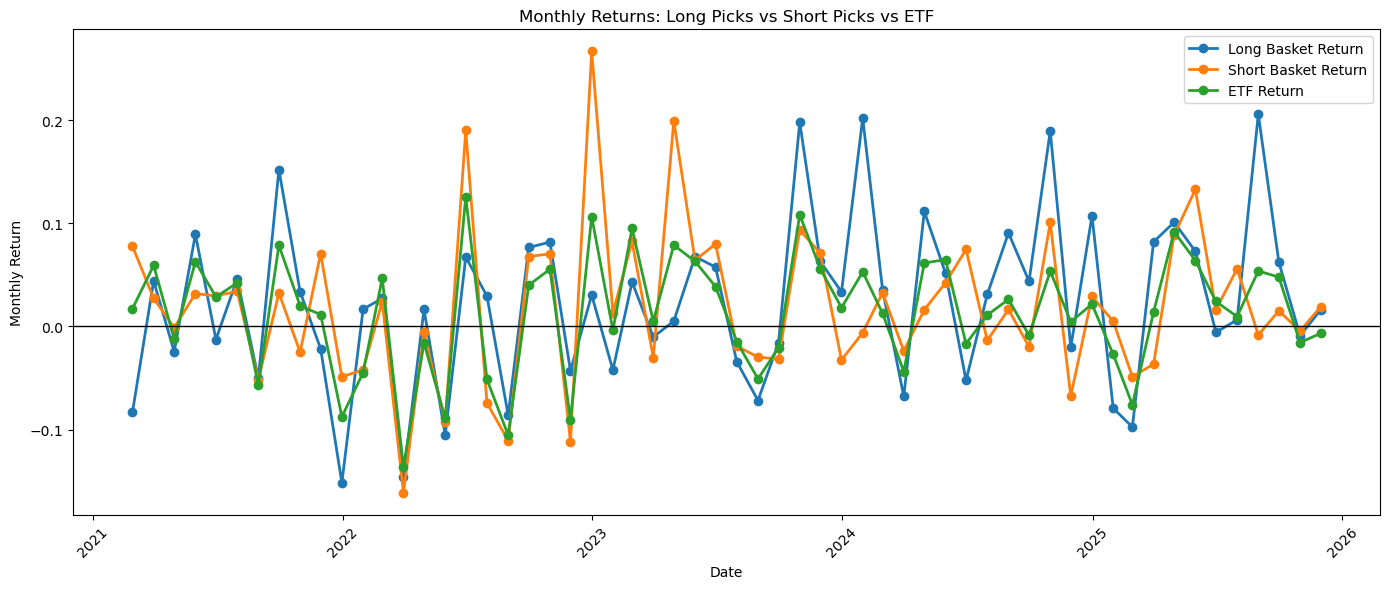

In [70]:
plt.figure(figsize=(14, 6))

plt.plot(
    backtest_df.index,
    backtest_df["Long Return"],
    marker="o",
    linewidth=2,
    label="Long Basket Return"
)

plt.plot(
    backtest_df.index,
    backtest_df["Short Return"],
    marker="o",
    linewidth=2,
    label="Short Basket Return"
)

plt.plot(
    backtest_df.index,
    backtest_df["ETF Return"],
    marker="o",
    linewidth=2,
    label="ETF Return"
)

plt.axhline(0, color="black", linewidth=1)

plt.title("Monthly Returns: Long Picks vs Short Picks vs ETF")
plt.xlabel("Date")
plt.ylabel("Monthly Return")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 8: Chart:

### 3. Cumulative portfolio return vs ETF

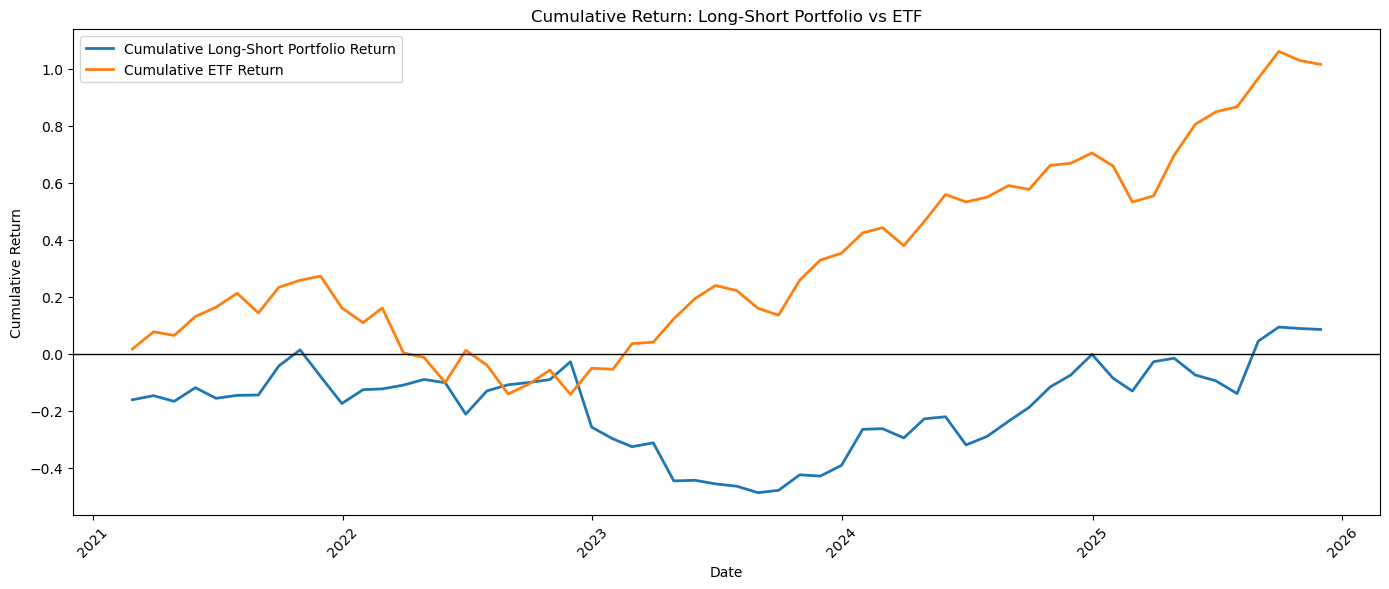

In [71]:
plt.figure(figsize=(14, 6))

plt.plot(
    backtest_df.index,
    backtest_df["Cumulative Portfolio Return"],
    linewidth=2,
    label="Cumulative Long-Short Portfolio Return"
)

plt.plot(
    backtest_df.index,
    backtest_df["Cumulative ETF Return"],
    linewidth=2,
    label="Cumulative ETF Return"
)

plt.axhline(0, color="black", linewidth=1)

plt.title("Cumulative Return: Long-Short Portfolio vs ETF")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [72]:
# Extra credit par

In [91]:
def monte_carlo_optimize_weights(returns_window, rf_annual=0.03, periods_per_year=12, 
                                 n_portfolios=50000, objective="max_sharpe", seed=42):
    """
    Monte Carlo portfolio optimizer.
    
    returns_window: historical monthly returns for selected stocks
    objective: "max_sharpe" or "min_vol"
    """

    returns_window = returns_window.dropna(axis=1)

    if returns_window.shape[1] == 0:
        return None

    tickers = returns_window.columns
    k = len(tickers)

    mu_annual = returns_window.mean() * periods_per_year
    cov_annual = returns_window.cov() * periods_per_year

    rng = np.random.default_rng(seed)

    results = []

    for _ in range(n_portfolios):
        weights = rng.random(k)
        weights = weights / weights.sum()

        exp_return = float(np.dot(weights, mu_annual.values))
        exp_var = float(weights.T @ cov_annual.values @ weights)
        exp_vol = float(np.sqrt(exp_var))

        sharpe = (exp_return - rf_annual) / exp_vol if exp_vol > 0 else -np.inf

        results.append((exp_return, exp_vol, sharpe, *weights))

    cols = ["ret", "vol", "sharpe"] + list(tickers)
    sim_df = pd.DataFrame(results, columns=cols)

    if objective == "max_sharpe":
        best_row = sim_df.loc[sim_df["sharpe"].idxmax()]
    elif objective == "min_vol":
        best_row = sim_df.loc[sim_df["vol"].idxmin()]
    else:
        raise ValueError("objective must be 'max_sharpe' or 'min_vol'")

    best_weights = best_row[tickers].astype(float)

    return best_weights

In [99]:
lookback_months = 12
num_stocks = 15

optimized_results = []

for i, date in enumerate(combined_z_score.index):

    if i < lookback_months:
        continue

    scores = combined_z_score.loc[date].dropna()

    if len(scores) < num_stocks * 2:
        continue

    long_tickers = scores.nlargest(num_stocks).index
    short_tickers = scores.nsmallest(num_stocks).index

    historical_window = monthly_returns.iloc[i-lookback_months:i]

    long_hist = historical_window[long_tickers]
    short_hist = historical_window[short_tickers]

    long_weights = monte_carlo_optimize_weights(
        long_hist,
        rf_annual=0.03,
        periods_per_year=12,
        n_portfolios=50000,
        objective="max_sharpe",
        seed=i
    )

    short_weights = monte_carlo_optimize_weights(
        short_hist,
        rf_annual=0.03,
        periods_per_year=12,
        n_portfolios=50000,
        objective="min_vol",
        seed=i+1000
    )

    if long_weights is None or short_weights is None:
        continue

    next_returns = next_month_returns.loc[date]

    long_return = (next_returns[long_weights.index] * long_weights).sum()
    short_return = (next_returns[short_weights.index] * short_weights).sum()

    optimized_portfolio_return = long_return - short_return

    etf_return = next_month_etf_returns.loc[date]

    optimized_results.append({
        "Date": date,
        "Long Return": long_return,
        "Short Return": short_return,
        "Portfolio Return": optimized_portfolio_return,
        "ETF Return": etf_return,
        "Long Tickers": list(long_weights.index),
        "Short Tickers": list(short_weights.index),
        "Long Weights": long_weights.to_dict(),
        "Short Weights": short_weights.to_dict()
    })

optimized_backtest_df = pd.DataFrame(optimized_results).set_index("Date")

In [103]:
optimized_backtest_df[["Long Return", "Short Return", "Portfolio Return", "ETF Return"]].tail()

,Long Return,Short Return,Portfolio Return,ETF Return
Date,,,,
2025-08-31,0.200246,0.004128,0.196118,0.053762
2025-09-30,0.083153,0.015524,0.067629,0.047804
2025-10-31,-0.019763,0.019680,-0.039443,-0.015610
2025-11-30,-0.029741,0.008350,-0.038090,-0.006699
2025-12-31,0.000000,0.000000,0.000000,NaN


In [104]:
print(type(optimized_results))

for a in optimized_results:
    print("long weights: ", a["Long Weights"], "\n", "short weights: ", a["Short Weights"])
    

# print weights
for a, b in zip(optimized_results["Long Weights"], optimized_results["Short Weights"]):
    print(a, b)
    # print("Long Weights:")
    # for ticker, weight in a.items():
    #     print(f"  {ticker}: {weight:.4f}")
    # print("Short Weights:")
    # for ticker, weight in b.items():
    #     print(f"  {ticker}: {weight:.4f}")
    # print("-" * 30 )
    

<class 'list'>
long weights:  {'TSLA': 0.06422408103822105, 'MSTR': 0.006220150836519093, 'PDD': 0.062469501944029074, 'CRWD': 0.05521885486249962, 'ZS': 0.17912269528114966, 'NVDA': 0.09189328849156997, 'MELI': 0.003994428960300767, 'DDOG': 0.018181162906354107, 'SHOP': 0.0009440405895893794, 'AXON': 0.16360682515034758, 'QCOM': 0.07323897652508186, 'MPWR': 0.12955714800699103, 'MRVL': 0.1404495467435376, 'PYPL': 0.003161686955011876, 'LRCX': 0.007717611708797466} 
 short weights:  {'GILD': 0.16681203657844182, 'INTC': 0.046874797314232865, 'VRTX': 0.09092230788096708, 'AEP': 0.06729303601038639, 'FER': 0.01052029447512544, 'REGN': 0.08772333735578244, 'XEL': 0.10186785434040453, 'CSCO': 0.009705994809667443, 'PEP': 0.024897466079667238, 'AMGN': 0.054067791090157524, 'MDLZ': 0.039064921843983316, 'EXC': 0.13072708365702915, 'WDC': 0.0007064899805025134, 'CCEP': 0.02060037905809567, 'ADP': 0.14821620952555659}
long weights:  {'MSTR': 0.05184238114496846, 'TSLA': 0.050350529668174424, '

TypeError: list indices must be integers or slices, not str

In [105]:
optimized_backtest_df["Cumulative Portfolio Return"] = (
    1 + optimized_backtest_df["Portfolio Return"]
).cumprod() - 1

optimized_backtest_df["Cumulative ETF Return"] = (
    1 + optimized_backtest_df["ETF Return"]
).cumprod() - 1

### Optimized Charts

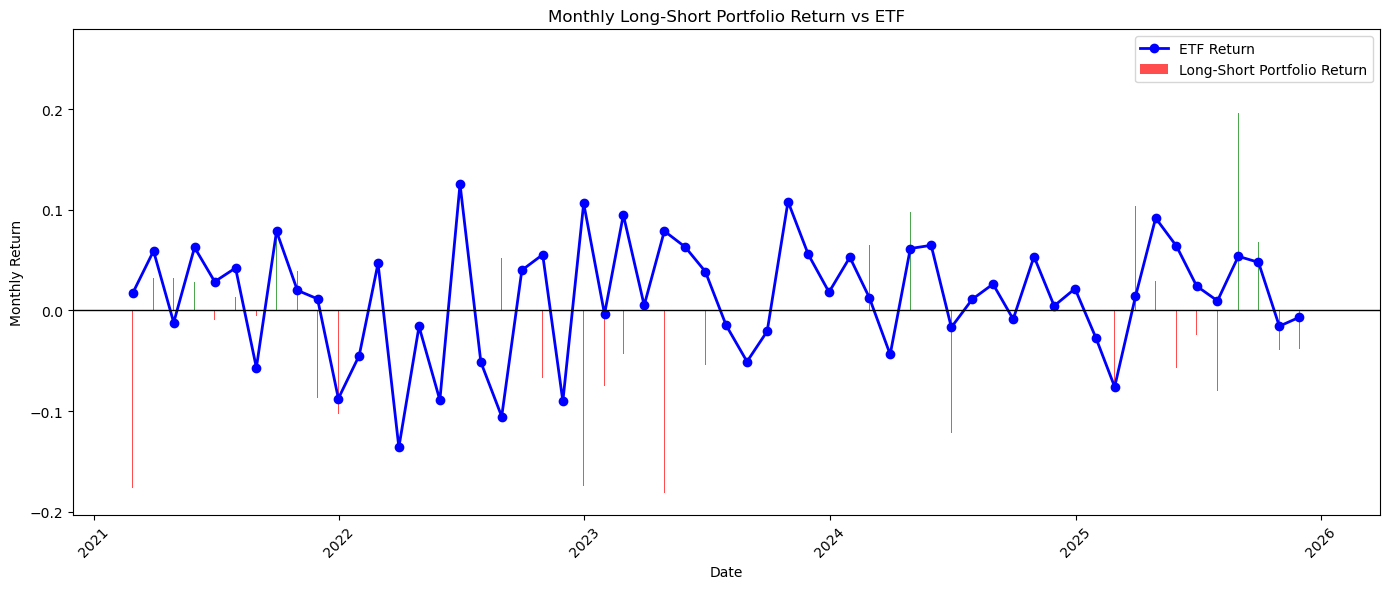

In [106]:
### chart 1

# Positive returns green, negative returns red
colors = np.where(optimized_backtest_df["Portfolio Return"] >= 0, "green", "red")

plt.figure(figsize=(14, 6))

plt.bar(
    optimized_backtest_df.index,
    optimized_backtest_df["Portfolio Return"],
    color=colors,
    alpha=0.7,
    label="Long-Short Portfolio Return"
)

plt.plot(
    optimized_backtest_df.index,
    optimized_backtest_df["ETF Return"],
    color="blue",
    marker="o",
    linewidth=2,
    label="ETF Return"
)

plt.axhline(0, color="black", linewidth=1)

plt.title("Monthly Long-Short Portfolio Return vs ETF")
plt.xlabel("Date")
plt.ylabel("Monthly Return")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


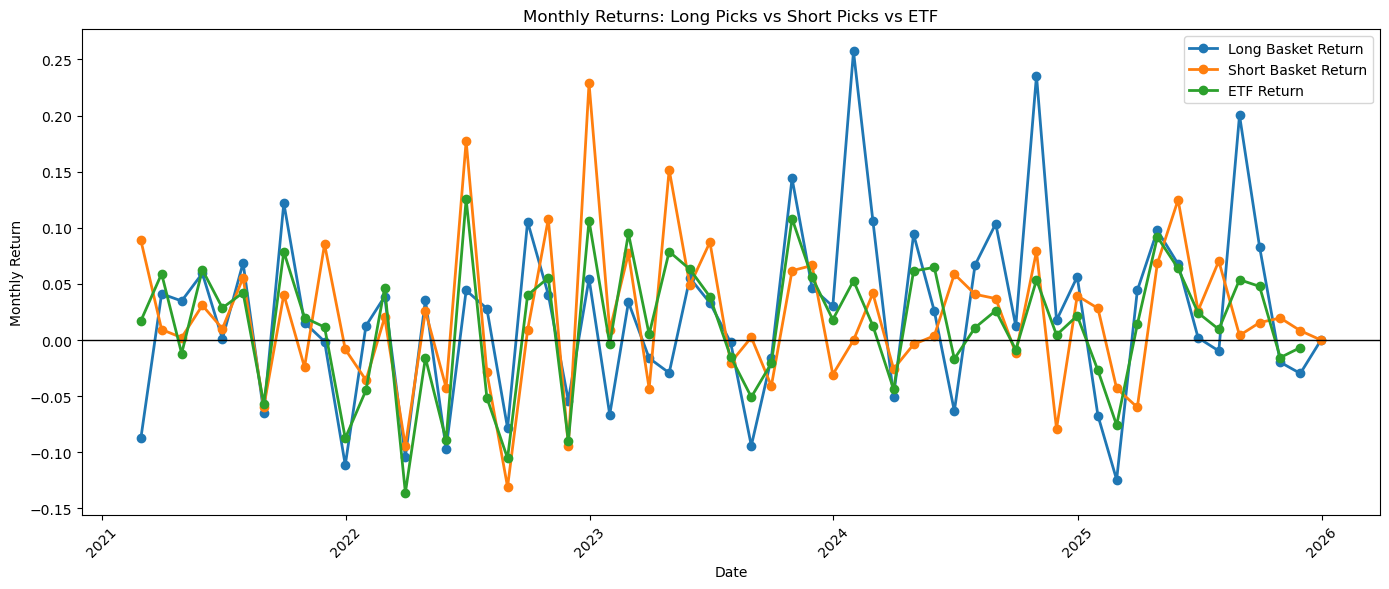

In [107]:
## chart 2

plt.figure(figsize=(14, 6))

plt.plot(
    optimized_backtest_df.index,
    optimized_backtest_df["Long Return"],
    marker="o",
    linewidth=2,
    label="Long Basket Return"
)

plt.plot(
    optimized_backtest_df.index,
    optimized_backtest_df["Short Return"],
    marker="o",
    linewidth=2,
    label="Short Basket Return"
)

plt.plot(
    optimized_backtest_df.index,
    optimized_backtest_df["ETF Return"],
    marker="o",
    linewidth=2,
    label="ETF Return"
)

plt.axhline(0, color="black", linewidth=1)

plt.title("Monthly Returns: Long Picks vs Short Picks vs ETF")
plt.xlabel("Date")
plt.ylabel("Monthly Return")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

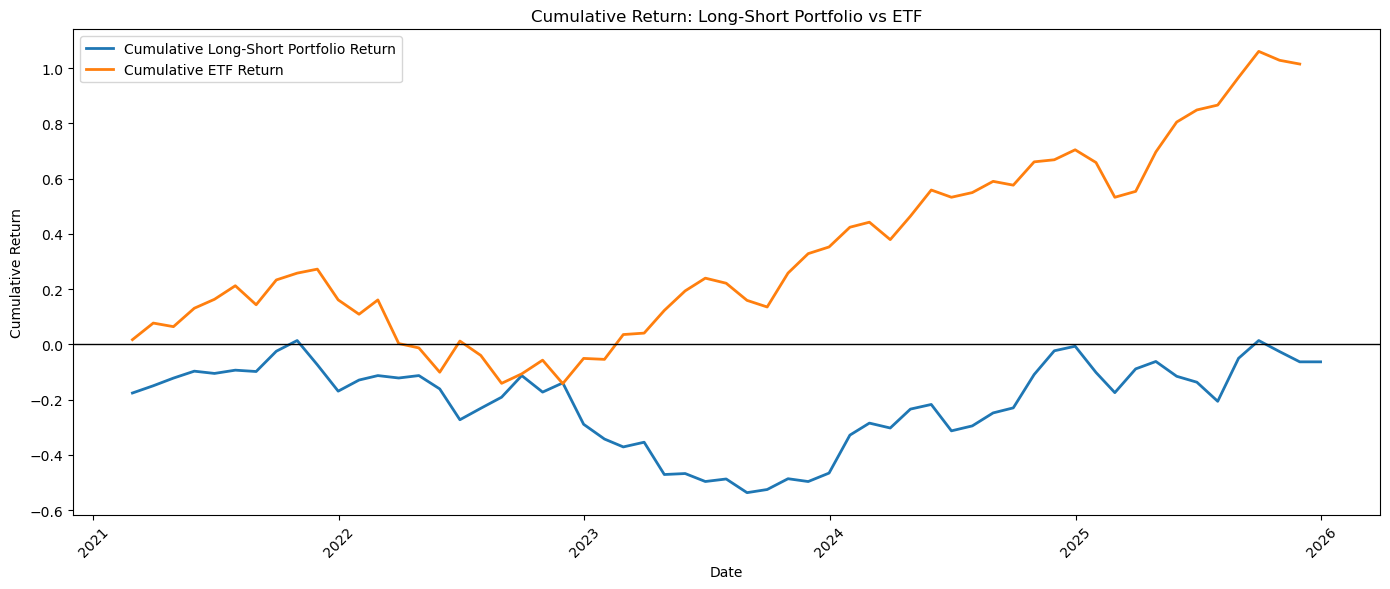

In [108]:
# chart 3
plt.figure(figsize=(14, 6))

plt.plot(
    optimized_backtest_df.index,
    optimized_backtest_df["Cumulative Portfolio Return"],
    linewidth=2,
    label="Cumulative Long-Short Portfolio Return"
)

plt.plot(
    optimized_backtest_df.index,
    optimized_backtest_df["Cumulative ETF Return"],
    linewidth=2,
    label="Cumulative ETF Return"
)

plt.axhline(0, color="black", linewidth=1)

plt.title("Cumulative Return: Long-Short Portfolio vs ETF")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()